Data loaded. Shape: (332675, 55)

KPI columns used: ['roa', 'ebitda_margin', 'debt_ratio', 'total_debt_to_equity', 'current_ratio', 'cash_ratio', 'interest_coverage', 'cfo_margin', 'free_cash_flow', 'asset_turnover', 'sales_growth', 'asset_growth', 'book_to_market', 'price_to_book', 'working_capital_to_assets', 'retained_earnings_to_assets']
KPI DataFrame shape: (332675, 16)


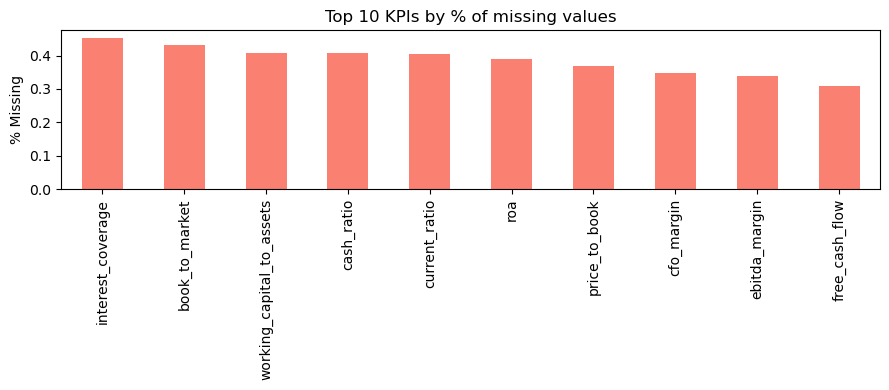

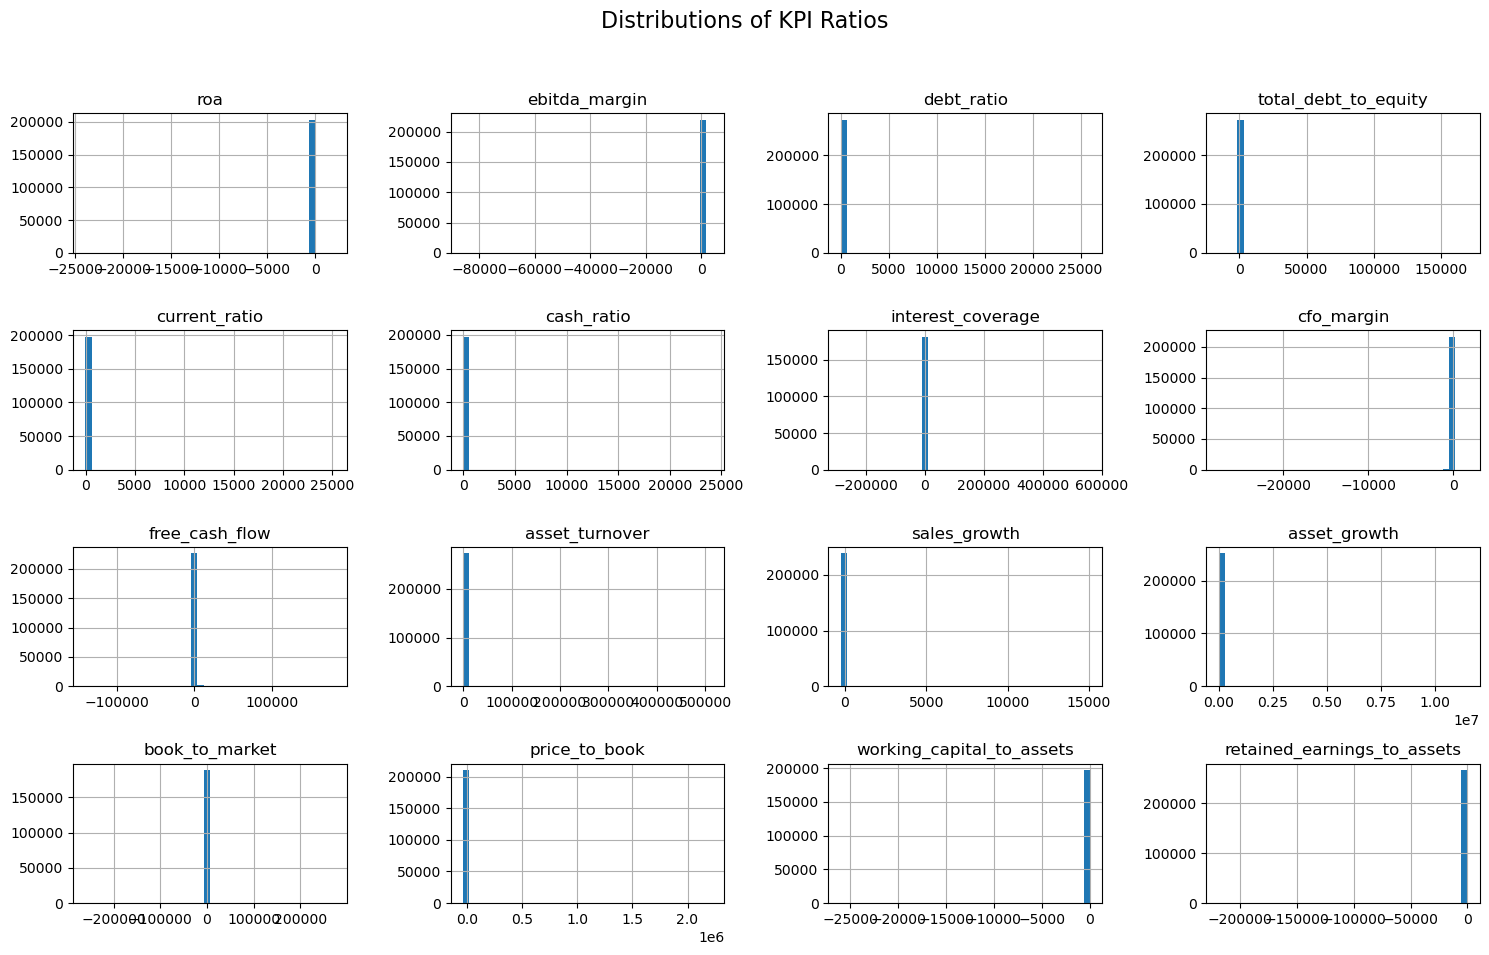

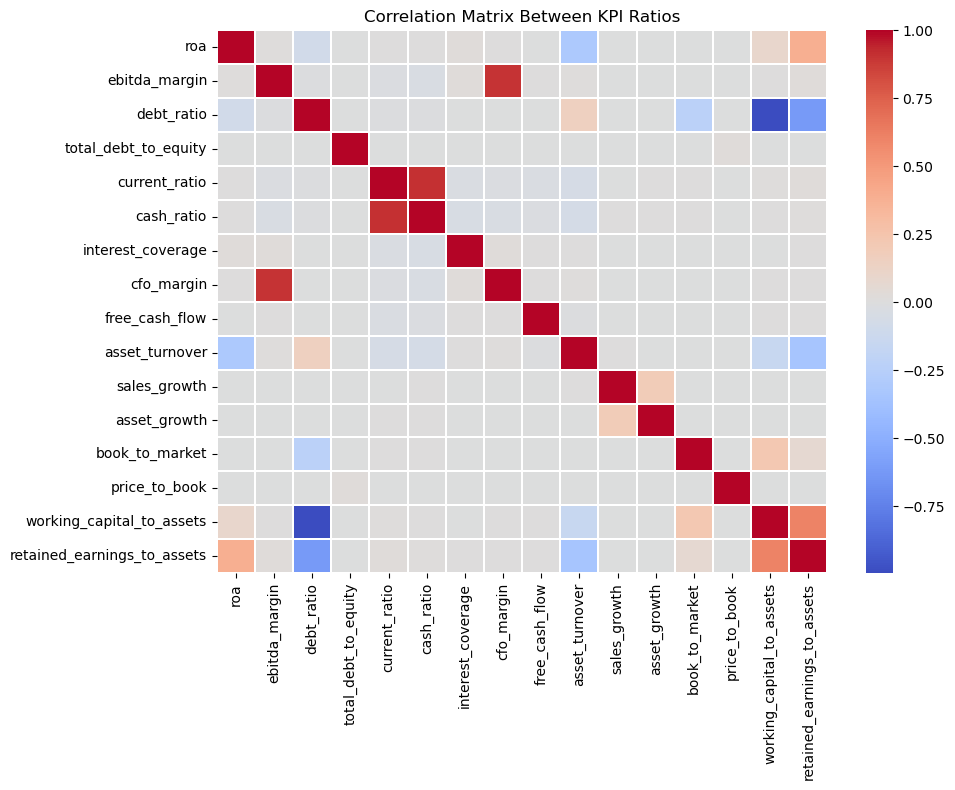

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

# -------------------------------------------------------------------
# Load dataset
# -------------------------------------------------------------------

data_path = "../data/processed/compustat_kpis.csv"
df = pd.read_csv(data_path)

print("Data loaded. Shape:", df.shape)

# -------------------------------------------------------------------
# Select KPI ratio columns ONLY
# -------------------------------------------------------------------

candidate_kpis = [
    "roa", "ebitda_margin", "debt_ratio", "total_debt_to_equity",
    "current_ratio", "cash_ratio", "interest_coverage",
    "cfo_margin", "free_cash_flow", "asset_turnover",
    "sales_growth", "asset_growth",
    "book_to_market", "price_to_book",
    "working_capital_to_assets",
    "retained_earnings_to_assets"
]

kpi_cols = [c for c in candidate_kpis if c in df.columns]
df_kpi = df[kpi_cols]

print("\nKPI columns used:", kpi_cols)
print("KPI DataFrame shape:", df_kpi.shape)

# -------------------------------------------------------------------
# Replace inf values and clean
# -------------------------------------------------------------------

df_kpi = df_kpi.replace([np.inf, -np.inf], np.nan)

# -------------------------------------------------------------------
# Missing values
# -------------------------------------------------------------------

missing_ratio = df_kpi.isna().mean().sort_values(ascending=False)
top_missing = missing_ratio.head(10)

plt.figure(figsize=(9,4))
top_missing.plot(kind="bar", color="salmon")
plt.title("Top 10 KPIs by % of missing values")
plt.ylabel("% Missing")
plt.tight_layout()
plt.show()

# -------------------------------------------------------------------
# Histograms
# -------------------------------------------------------------------

df_hist = df_kpi.dropna(axis=1, how="all")

n = len(df_hist.columns)
if n > 0:
    rows = int(np.ceil(n / 4))
    df_hist.hist(
        bins=40,
        figsize=(15, 10),
        layout=(rows, 4),
        sharex=False, sharey=False
    )
    plt.suptitle("Distributions of KPI Ratios", fontsize=16)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()
else:
    print("⚠️ No valid KPI columns for histograms.")

# -------------------------------------------------------------------
# Correlation matrix
# -------------------------------------------------------------------

df_corr = df_kpi.dropna()

if len(df_corr.columns) > 1:
    corr = df_corr.corr()

    plt.figure(figsize=(10, 8))
    sns.heatmap(
        corr,
        cmap="coolwarm",
        center=0,
        annot=False,
        linewidths=0.3
    )
    plt.title("Correlation Matrix Between KPI Ratios")
    plt.tight_layout()
    plt.show()
else:
    print("⚠️ No valid KPI columns for correlation matrix.")
